In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('default')

print("Libraries Imported Successfully")


Libraries Imported Successfully


In [2]:
from google.colab import files

uploaded = files.upload()

Saving Unemployment in India.csv to Unemployment in India.csv


In [4]:
df = pd.read_csv('/content/Unemployment in India.csv')

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [5]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

Shape of Dataset:
(768, 7)

Column Names:
Index(['Region', ' Date', ' Frequency', ' Estimated Unemployment Rate (%)',
       ' Estimated Employed', ' Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtype

In [6]:
df.columns = df.columns.str.strip()

print(df.columns)

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')


In [7]:
df['Date'] = pd.to_datetime(df['Date'])

df.head()

/tmp/ipykernel_628/3300519020.py:1: UserWarning: Parsing dates in  %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,2019-06-30,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,2019-07-31,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,2019-08-31,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,2019-09-30,Monthly,5.17,12256762.0,44.68,Rural


In [8]:
df.describe()

,Date,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740,740.000000,7.400000e+02,740.000000
mean,2019-12-12 18:36:58.378378496,11.787946,7.204460e+06,42.630122
min,2019-05-31 00:00:00,0.000000,4.942000e+04,13.330000
25%,2019-08-31 00:00:00,4.657500,1.190404e+06,38.062500
50%,2019-11-30 00:00:00,8.350000,4.744178e+06,41.160000
75%,2020-03-31 00:00:00,15.887500,1.127549e+07,45.505000
max,2020-06-30 00:00:00,76.740000,4.577751e+07,72.570000
std,NaN,10.721298,8.087988e+06,8.111094


In [9]:
avg_rate = df['Estimated Unemployment Rate (%)'].mean()

print("Average Unemployment Rate:", round(avg_rate,2), "%")

Average Unemployment Rate: 11.79 %


In [10]:
state_avg = df.groupby('Region')['Estimated Unemployment Rate (%)'] \
              .mean() \
              .sort_values(ascending=False)

print(state_avg.head(10))

Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Delhi               16.495357
Jammu & Kashmir     16.188571
Chandigarh          15.991667
Rajasthan           14.058214
Uttar Pradesh       12.551429
Name: Estimated Unemployment Rate (%), dtype: float64


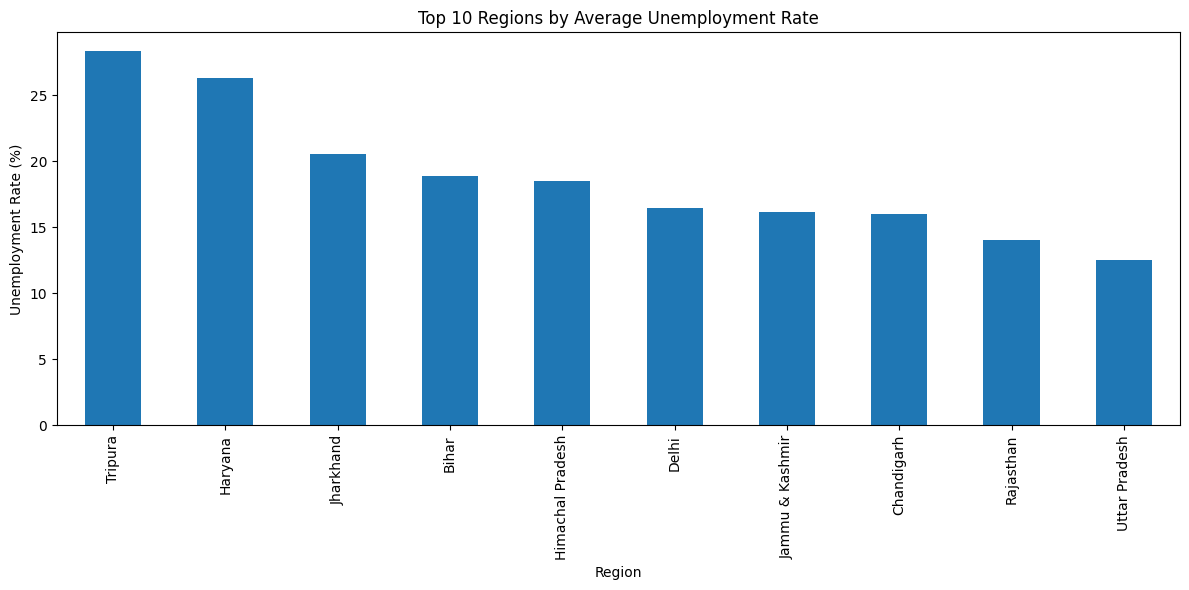

In [11]:
plt.figure(figsize=(12,6))

state_avg.head(10).plot(kind='bar')

plt.title('Top 10 Regions by Average Unemployment Rate')
plt.xlabel('Region')
plt.ylabel('Unemployment Rate (%)')

plt.tight_layout()
plt.show()

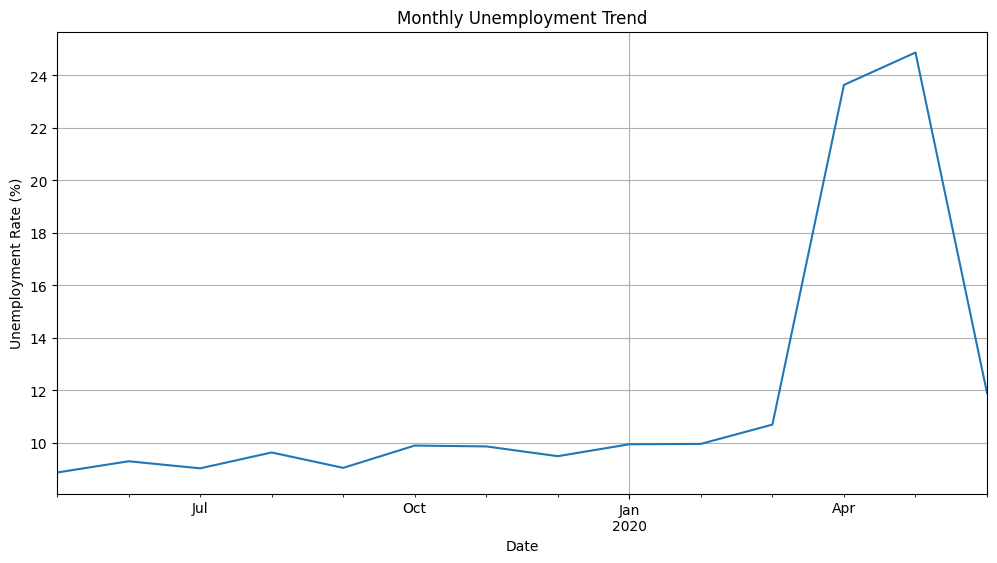

In [12]:
monthly_trend = df.groupby('Date')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(12,6))

monthly_trend.plot()

plt.title('Monthly Unemployment Trend')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')

plt.grid(True)

plt.show()

In [13]:
df['Year'] = df['Date'].dt.year

covid_analysis = df.groupby('Year')['Estimated Unemployment Rate (%)'].mean()

print(covid_analysis)

Year
2019.0     9.399047
2020.0    15.101581
Name: Estimated Unemployment Rate (%), dtype: float64


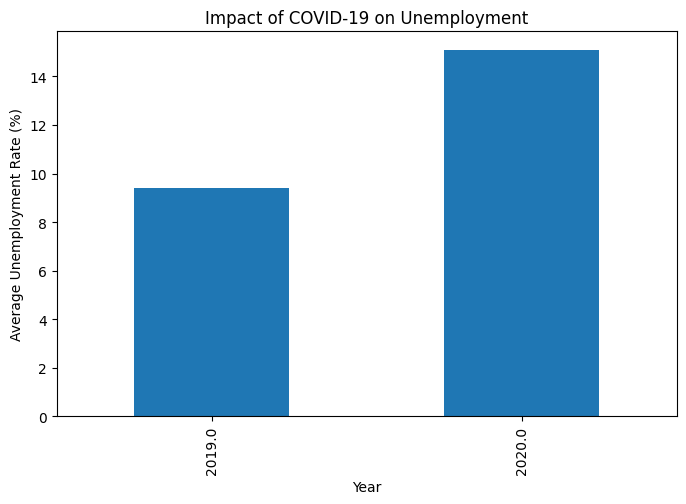

In [14]:
plt.figure(figsize=(8,5))

covid_analysis.plot(kind='bar')

plt.title('Impact of COVID-19 on Unemployment')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

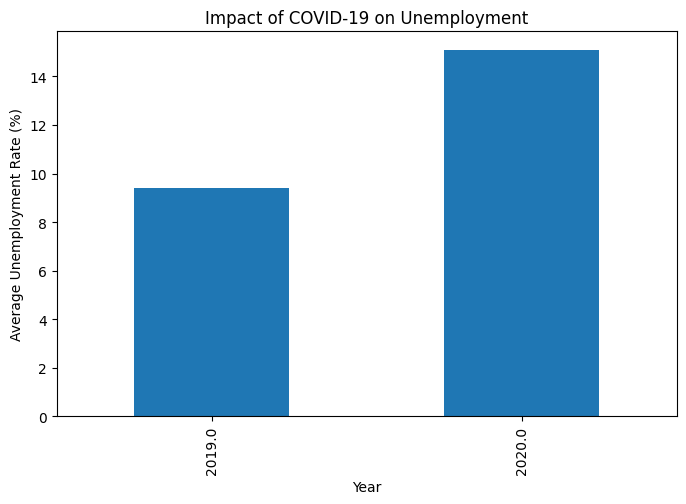

In [15]:
plt.figure(figsize=(8,5))

covid_analysis.plot(kind='bar')

plt.title('Impact of COVID-19 on Unemployment')
plt.xlabel('Year')
plt.ylabel('Average Unemployment Rate (%)')

plt.show()

In [16]:
area_analysis = df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

print(area_analysis)

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64


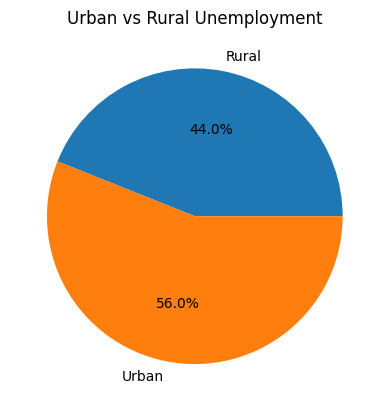

In [17]:
area_analysis.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Urban vs Rural Unemployment')

plt.ylabel('')

plt.show()

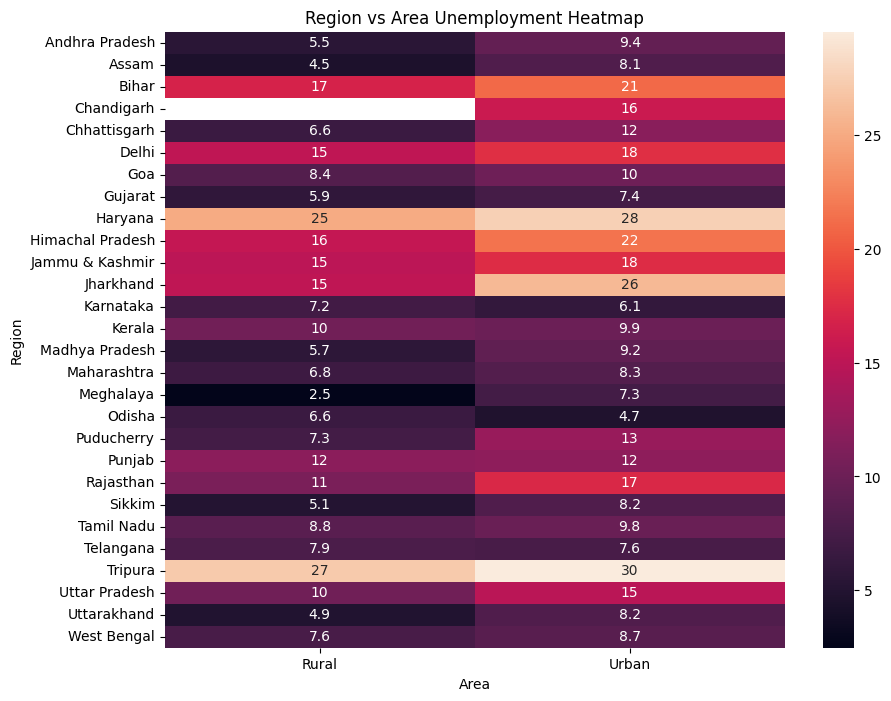

In [18]:
pivot_table = pd.pivot_table(
    df,
    values='Estimated Unemployment Rate (%)',
    index='Region',
    columns='Area'
)

plt.figure(figsize=(10,8))

sns.heatmap(
    pivot_table,
    annot=True
)

plt.title('Region vs Area Unemployment Heatmap')

plt.show()

In [19]:
top10 = df.nlargest(
    10,
    'Estimated Unemployment Rate (%)'
)

top10[
    ['Region',
     'Date',
     'Estimated Unemployment Rate (%)']
]

,Region,Date,Estimated Unemployment Rate (%)
627,Puducherry,2020-04-30,76.74
628,Puducherry,2020-05-31,75.00
242,Puducherry,2020-04-30,74.51
531,Jharkhand,2020-05-31,70.17
530,Jharkhand,2020-04-30,61.48
412,Bihar,2020-04-30,58.77
145,Jharkhand,2020-05-31,55.10
287,Tamil Nadu,2020-04-30,53.19
507,Himachal Pradesh,2020-05-31,50.00
38,Bihar,2020-05-31,47.26


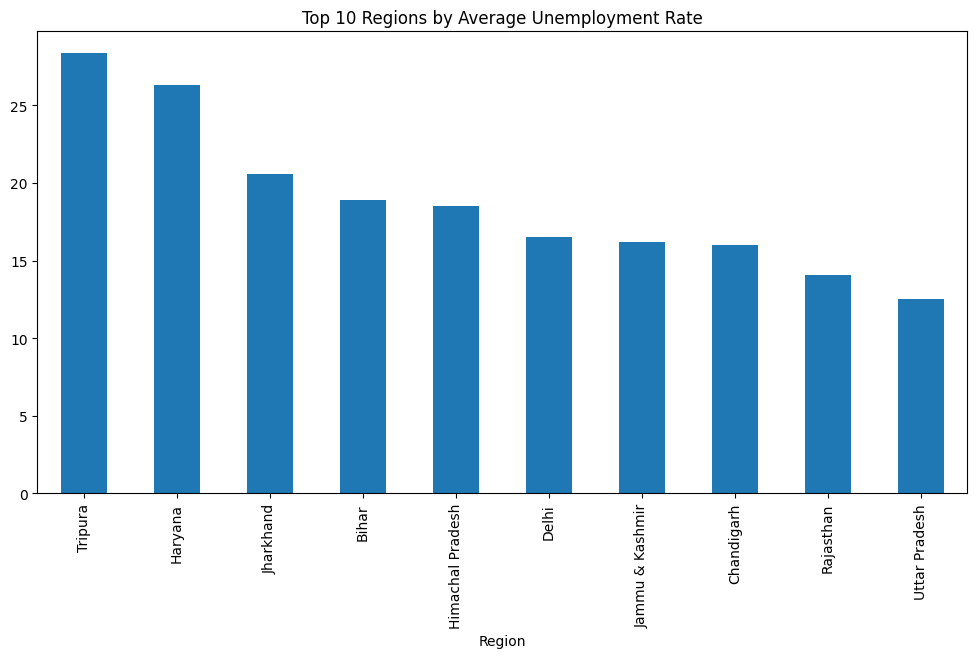

In [20]:
plt.figure(figsize=(12,6))

state_avg.head(10).plot(kind='bar')

plt.title('Top 10 Regions by Average Unemployment Rate')

plt.savefig('top10_regions.png')

plt.show()

In [21]:
print("""
KEY INSIGHTS

1. Unemployment rose significantly during the COVID period.

2. Certain regions consistently recorded higher unemployment rates.

3. Urban and Rural areas showed different unemployment patterns.

4. Regional analysis helps identify areas requiring policy intervention.

5. Data visualization makes unemployment trends easier to understand.
""")


KEY INSIGHTS

1. Unemployment rose significantly during the COVID period.

2. Certain regions consistently recorded higher unemployment rates.

3. Urban and Rural areas showed different unemployment patterns.

4. Regional analysis helps identify areas requiring policy intervention.

5. Data visualization makes unemployment trends easier to understand.

